## AB Testi, Sampling ve Betimsel İstatistik

### AB Testi (A/B Testing) Nedir?
AB Testi, bir değişkenin (örneğin web sitesi arayüzü, kampanya, öneri modeli) iki farklı versiyonunun (A ve B grupları) etkilerini karşılaştırmak için kullanılan istatistiksel bir test yöntemidir. Amaç, hangi versiyonun belirlenen bir başarı kriterine göre daha iyi performans gösterdiğini anlamaktır.

Tipik adımlar:
- **Hipotezlerin Kurulması**:  
  - *H0 (Null Hypotez)*: İki grup arasında anlamlı bir fark yoktur.  
  - *H1 (Alternatif Hipotez)*: İki grup arasında anlamlı bir fark vardır.
- **Grupların Belirlenmesi**: Kullanıcılar veya gözlemler rastgele şekilde A ve B gruplarına atanır.
- **Testin Uygulanması**: Belirlenen süre boyunca iki grup üzerinde deney yürütülür.
- **Analiz ve Karar**: Sonuçlar istatistiksel testlerle analiz edilir ve anlamlılık değerlendirilir.

---

### Sampling (Örnekleme)
Örnekleme, genellikle tüm popülasyonu incelemek maliyetli olduğu için, popülasyondan rastgele veya belirli yöntemlerle bir alt küme (örneklem) seçme sürecidir. AB testlerinde de kullanıcılar genellikle random sampling veya stratified sampling gibi yöntemlerle iki gruba ayrılır.

- **Random Sampling**: Her kullanıcının A veya B grubuna seçilme olasılığı eşittir.
- **Stratified Sampling**: Popülasyon belirli katmanlara ayrılır ve her katmandan orantılı olarak örnek seçilir.

Örnekleme işlemi, örneklerin temsiliyeti ve test gücünü sağlamak için önemlidir. Ayrıca, örneklem büyüklüğü (sample size), istatistiksel testlerin güvenilirliği açısından kritik bir parametredir.

---

### Betimsel İstatistik (Descriptive Statistics)
Betimsel istatistik, gruplara ait temel istatistiksel değerleri özetler ve karşılaştırmayı kolaylaştırır. AB testi için sıkça kullanılan betimsel istatistikler şunlardır:

- **Ortalama (Mean)**: Her bir grubun ortalama performans skoru.
- **Medyan (Median)**: Ortanca değer; uç değerlerin etkisini azaltmak için kullanışlıdır.
- **Standart Sapma (Standard Deviation)**: Gözlemlerin ortalamadan sapma miktarı, yani veri yayılımı.
- **Minimum ve Maksimum Değerler**
- **Varyans**: Değerlerin ne kadar yayıldığını gösterir.

Deskriptif istatistikler, gruplar arasında başlangıçta anlamlı bir fark olup olmadığını ya da test sonrası değişimi anlamamıza yardımcı olur. Ayrıca, grupların homojenliğini ve uç değerlerin varlığını değerlendirmek için de kullanılır.

---

**Özetle:**  
AB testi süreci; rastgele veya katmanlı örnekleme (sampling), grupların tanımlanması ve karşılaştırılması için betimsel istatistiklerin hesaplanması adımları ile başlar. Sonrasında uygun istatistiksel testlerle (örneğin t-testi, ki-kare testi) gruplar arasındaki farkın anlamlı olup olmadığı test edilir.

In [2]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# !pip install statsmodels
import statsmodels.stats.api as sms
from scipy.stats import ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu, \
    pearsonr, spearmanr, kendalltau, f_oneway, kruskal
from statsmodels.stats.proportion import proportions_ztest

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
pd.set_option('display.float_format', lambda x: '%.5f' % x)


In [3]:
populasyon = np.random.randint(0,80,1000000)
populasyon.mean()

np.float64(39.475385)

In [4]:
np.random.seed(115)

In [5]:
# Popülasyonumuzdan rastgele 100 tane örnek seçiyoruz ve bunların ortalamasını alıyoruz.
orneklem = np.random.choice(populasyon, 100)   # np.random.choice ile, populasyondan 100 adet rasgele değer seçiyoruz (örneklem oluşturma)
print("Örneklem Ortalaması:", orneklem.mean()) # Seçilen örneklemin ortalamasını ekrana yazdırıyoruz



Örneklem Ortalaması: 40.79


In [6]:
orneklem1 = np.random.choice(populasyon, size=100)
orneklem2 = np.random.choice(populasyon, size=100)
orneklem3 = np.random.choice(populasyon, size=100)
orneklem4 = np.random.choice(populasyon, size=100)
orneklem5 = np.random.choice(populasyon, size=100)
orneklem6 = np.random.choice(populasyon, size=100)
orneklem7 = np.random.choice(populasyon, size=100)
orneklem8 = np.random.choice(populasyon, size=100)
orneklem9 = np.random.choice(populasyon, size=100)
orneklem10 = np.random.choice(populasyon, size=100)

print(
    (orneklem1.mean()
     + orneklem2.mean()
     + orneklem3.mean()
     + orneklem4.mean()
     + orneklem5.mean()
     + orneklem6.mean()
     + orneklem7.mean()
     + orneklem8.mean()
     + orneklem9.mean()
     + orneklem10.mean()) / 10
)

38.605


### Betimsel İstatistik

In [7]:
df = sns.load_dataset("tips")
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.00000,19.78594,8.90241,3.07000,13.34750,17.79500,24.12750,50.81000
tip,244.00000,2.99828,1.38364,1.00000,2.00000,2.90000,3.56250,10.00000
size,244.00000,2.56967,0.95110,1.00000,2.00000,2.00000,3.00000,6.00000


### Güven Aralığı
Güven aralığı, bir popülasyon parametresinin (örneğin ortalamasının) tahmini değerinin etrafında, belirli bir güven düzeyinde (genellikle %95 veya %99) yer alması beklenen aralıktır. Başka bir deyişle, elde ettiğimiz örneklem istatistiğinin popülasyondaki gerçek değere ne kadar yakın olduğunu ve bu tahmine ne kadar güvenebileceğimizi gösterir.

Bu kavrama örnekle açıklayalım: Diyelim ki bir restoranın tüm müşterilerinin ödediği ortalama toplam hesabı öğrenmek istiyoruz, fakat tüm müşterilere erişemiyoruz. Bunun yerine rastgele bir örneklem seçip, o örneklemdeki ortalamayı hesaplıyoruz. Fakat her seçtiğimiz örneklemde, ortalama bir miktar değişebilir. Güven aralığı, işte bu örneklem ortalamasının etrafında, popülasyon ortalamasının hangi aralıkta bulunabileceğini belirtir.

Genellikle %95 güven aralığı kullanılır. Bu, aynı büyüklükte ve aynı yöntemle birçok kez örneklem alsaydık, oluşturduğumuz güven aralıklarının yaklaşık %95'inin popülasyon ortalamasını kapsayacağı anlamına gelir.

Güven aralığı, istatistiksel olarak bulduğumuz sonuçların ne kadar güvenilir ve genellenebilir olduğuna dair kritik bir ölçüdür.

Şimdi adım adım güven aralığı hesaplamasına değinelim:

Adım 1: n, ortalama ve standart sapmayı bul.
Örneğin: n = 100, ortalama = 180, standart sapma = 40

Adım 2: Güven düzeyine karar ver (örn., %95 için z = 1.96).

Adım 3: Güven aralığını hesapla:
    Güven Aralığı Formülü:
        ortalama ± z * (standart sapma / sqrt(n))
    Örneğimizde:
        180 ± 1.96 × (40 / sqrt(100)) = 180 ± 1.96 × 4 = 180 ± 7.84
    Yani güven aralığı: [172.16, 187.84]

Sonuç olarak, popülasyon ortalamasının %95 güvenle 172 ile 188 arasında olduğu söylenebilir.

In [8]:
df = sns.load_dataset("tips")
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.00000,19.78594,8.90241,3.07000,13.34750,17.79500,24.12750,50.81000
tip,244.00000,2.99828,1.38364,1.00000,2.00000,2.90000,3.56250,10.00000
size,244.00000,2.56967,0.95110,1.00000,2.00000,2.00000,3.00000,6.00000


In [9]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99000,1.01000,Female,No,Sun,Dinner,2
1,10.34000,1.66000,Male,No,Sun,Dinner,3
2,21.01000,3.50000,Male,No,Sun,Dinner,3
3,23.68000,3.31000,Male,No,Sun,Dinner,2
4,24.59000,3.61000,Female,No,Sun,Dinner,4


In [10]:
# Burada, 'total_bill' değişkeninin %95 güven aralığını hesaplıyoruz.
# Bu, toplam hesabın ortalamasının, örneklemimizden yola çıkarak tüm popülasyonda hangi aralıkta olabileceğini gösterir.
# sms.DescrStatsW ile tanımlayıcı istatistikler elde ediliyor ve tconfint_mean() fonksiyonu ile ortalamanın güven aralığı hesaplanıyor.
sms.DescrStatsW(df["total_bill"]).tconfint_mean()

(np.float64(18.663331704357976), np.float64(20.908553541543657))

In [11]:
sms.DescrStatsW(df["tip"]).tconfint_mean()

(np.float64(2.823799306281744), np.float64(3.1727580707674363))

In [12]:
df = sns.load_dataset("titanic")
sms.DescrStatsW(df["age"].dropna()).tconfint_mean()

(np.float64(28.631790041821503), np.float64(30.766445252296137))

In [13]:
sms.DescrStatsW(df["fare"].dropna()).tconfint_mean()

(np.float64(28.936831234567336), np.float64(35.47158470258195))

## Korelasyon (Correlation) Nedir?

Korelasyon, iki veya daha fazla değişken arasındaki ilişkiyi, bu ilişkinin yönünü (pozitif/negatif) ve şiddetini gösteren istatistiksel bir ölçüdür. Korelasyon, değişkenler birlikte arttığında ya da azaldığında pozitif, birisi artarken diğeri azaldığında ise negatif olur. Korelasyon katsayısı genellikle "-1" ile "+1" arasında bir değer alır.

### Korelasyon Katsayısı (r) Değerleri ve Yorumları

- **+1:** Mükemmel pozitif korelasyon. İki değişken tamamen aynı doğrultuda hareket eder.
- **+0.9:** Yüksek pozitif korelasyon. Değişkenler büyük oranda aynı şekilde değişir.
- **+0.5:** Düşük pozitif korelasyon. Aralarında zayıf, ama yine de pozitif bir ilişki vardır.
- **0:** Korelasyon yoktur. Değişkenler arasında doğrusal bir ilişki yoktur.
- **-0.5:** Düşük negatif korelasyon. Değişkenlerden biri artarken diğeri azalma eğilimindedir, ancak ilişki zayıftır.
- **-0.9:** Yüksek negatif korelasyon. Değişkenlerden biri artarken diğeri büyük ölçüde azalır.
- **-1:** Mükemmel negatif korelasyon. Değişkenler tamamen zıt yönlerde hareket eder.

 Negatif korelasyon varlığında değerler zıt yönlere hareket eder.

Korelasyon, nedensellik (causation) anlamına gelmez, yalnızca iki değişken arasındaki doğrusal ilişkiyi ifade eder.

In [14]:
df = sns.load_dataset("tips")
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99000,1.01000,Female,No,Sun,Dinner,2
1,10.34000,1.66000,Male,No,Sun,Dinner,3
2,21.01000,3.50000,Male,No,Sun,Dinner,3
3,23.68000,3.31000,Male,No,Sun,Dinner,2
4,24.59000,3.61000,Female,No,Sun,Dinner,4


In [15]:
df["total_bill"] = df["total_bill"] - df["tip"]

<Axes: xlabel='tip', ylabel='total_bill'>

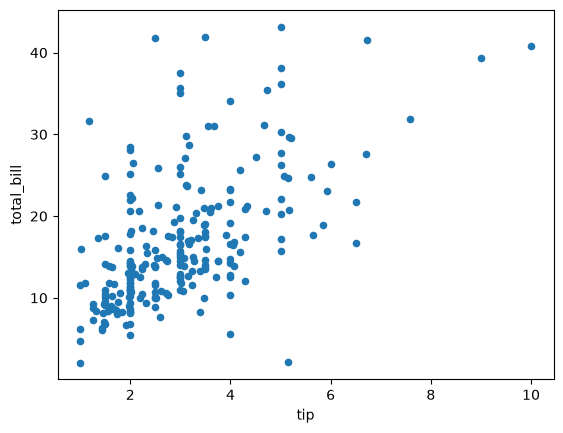

In [17]:
df.plot.scatter(x="tip", y="total_bill")

In [18]:
# 'tip' ve 'total_bill' arasındaki Pearson korelasyon katsayısını hesaplayalım:
correlation = df["tip"].corr(df["total_bill"])
print(f"'tip' ile 'total_bill' arasındaki korelasyon katsayısı: {correlation}")

# Korelasyon katsayısı, iki değişken arasındaki doğrusal ilişkiyi ölçer.
# Pozitif bir değer, iki değişkenin birlikte arttığını gösterir.
# Negatif bir değer ise bir değişken artarken diğerinin azaldığını belirtir.
# 0'a yakın bir değer, değişkenler arasında doğrusal bir ilişki olmadığını gösterir.
# Bu örnekte elde edilen korelasyon katsayısını yorumlayarak bahşiş (tip) ile toplam hesap (total_bill) arasındaki ilişkiyi anlayabiliriz.

'tip' ile 'total_bill' arasındaki korelasyon katsayısı: 0.5766634471096382


"""
## Hipotez Testleri (Hypothesis Testing)

Hipotez testleri, bir örneklemden elde edilen verilerle belirli bir varsayımın, yani hipotezin doğru olup olmadığını istatistiksel olarak değerlendirmek için kullanılan yöntemlerdir. Temel amaç, topluluk hakkında bir iddiada bulunmak ve bu iddiayı veriyle test etmektir.

Hipotez testlerinde iki temel hipotez kurulur:
- **Null Hipotezi (H0):** Genel olarak "fark yoktur" veya "etki yoktur" şeklinde tanımlanır.
- **Alternatif Hipotez (H1 veya Ha):** "Fark vardır" veya "etki vardır" iddiasını ortaya koyar.

### Hipotez Testinin Adımları
1. Hipotezleri tanımla (H0 ve H1).
2. Uygun test yöntemini seç (örneğin: t-testi, ki-kare testi, ANOVA).
3. Test istatistiğini ve p-değerini hesapla.
4. Anlamlılık düzeyini (genellikle α = 0.05) belirle.
5. P-değerini yorumla:
    - p < α ise, H0 reddedilip H1 kabul edilir.
    - p ≥ α ise, H0 reddedilemez.

Hipotez testleri, A/B testleri gibi uygulamalarda veya bir müdahalenin etkisini değerlendirmede yaygın olarak kullanılır.
"""

## Bağımsız İki Örneklem t Testi (AB Testi) Nedir?

Bağımsız iki örneklem t testi (independent two-sample t-test), iki farklı grup arasında bir ortalama farkı olup olmadığını anlamak için kullanılan parametrik bir istatistiksel testtir. A/B testi olarak bilinen uygulamalarda da en sık tercih edilen testlerden biridir.

### Temel Özellikler:
- Gruplar bağımsızdır: Her gözlem sadece bir gruba aittir (örn. A ve B gruplarındaki kullanıcılar farklıdır).
- Amaç: İki grubun ortalamaları arasında anlamlı bir fark olup olmadığını tespit etmek.

### Kullanım Alanları:
- Web sitelerinde yeni bir tasarımın mevcut tasarıma kıyasla performansını değerlendirmek
- Pazarlama kampanyasında iki farklı stratejinin satışa etkisini karşılaştırmak
- İlaç denemelerinde tedavi ve kontrol gruplarındaki ortalama iyileşme farkını analiz etmek

### Hipotezler:
- Null Hipotezi (H0): Grup ortalamaları arasında fark yoktur. (μ1 = μ2)
- Alternatif Hipotez (H1): Grup ortalamaları arasında fark vardır. (μ1 ≠ μ2)

### Yorumlama:
Eğer test sonucu elde edilen p-değeri genellikle 0.05'ten küçükse, iki grup arasında istatistiksel olarak anlamlı bir fark olduğu söylenir ve H0 reddedilir.

Özellikle AB testleri çerçevesinde, yeni bir değişikliğin gerçekten anlamlı bir etkisi olup olmadığını nesnel olarak değerlendirmek için bu testten yararlanılır.

In [19]:

###############################################################
# AB Testing (Bağımsız İki Örneklem T Testi)
###############################################################

# 1. Hipotezleri Kur
# 2. Varsayım Kontrolü
#    1. Normallik Varsayımı
#    2. Varyans Homojenliği
# 3. Hipotezin Uygulanması
#    1. Varsayımlar sağlanıyorsa bağımsız iki örneklem t testi (parametrik test)
#    2. Varsayımlar sağlanmıyorsa mannwhitney testi (non-parametrik test)
# Not:
# - Normallik sağlanmıyorsa direkt 2 numara. Varyans homojenliği sağlanmıyorsa 1 numaraya arguman girilir.
# - Normallik incelenmesi öncesi aykırı değer incelenmesi ve düzeltmesi yapmak faydalı olabilir.

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99000,1.01000,Female,No,Sun,Dinner,2
1,10.34000,1.66000,Male,No,Sun,Dinner,3
2,21.01000,3.50000,Male,No,Sun,Dinner,3
3,23.68000,3.31000,Male,No,Sun,Dinner,2
4,24.59000,3.61000,Female,No,Sun,Dinner,4


In [20]:
df.groupby("smoker").agg({"total_bill": "mean"})

,total_bill
smoker,
Yes,20.75634
No,19.18828


In [ ]:
# 1. Hipotezleri Kur
# H0: Grup ortalamaları arasında fark yoktur. (μ1 = μ2)
# H1: Grup ortalamaları arasında fark vardır. (μ1 ≠ μ2)

# 2. Varsayım Kontrolü
#    1. Normallik Varsayımı
#    2. Varyans Homojenliği

# "smoker" değişkeni "Yes" olanların "total_bill" değerleri için normallik varsayımını Shapiro-Wilk testi ile kontrol ediyoruz.
test_stat, p_value = shapiro(df.loc[df["smoker"] == "Yes", "total_bill"])
print('Test Stat = %.4f, p-value = %.4f' % (test_stat, p_value))

Test Stat = 0.9367, p-value = 0.0002


In [24]:
test_stat, p_value = shapiro(df.loc[df["smoker"] == "No", "total_bill"])
print('Test Stat = %.4f, p-value = %.4f' % (test_stat, p_value))

Test Stat = 0.9045, p-value = 0.0000


In [25]:
## Varyans Homojenliği
# Varyans homojenliği varsayımı, iki grup arasındaki varyansların eşit olması gerektiğini belirtir.
test_stat, p_value = levene(df.loc[df["smoker"] == "Yes", "total_bill"], df.loc[df["smoker"] == "No", "total_bill"])
print('Test Stat = %.4f, p-value = %.4f' % (test_stat, p_value))
# Varyans homojenliği varsayımının sağlanması gerektiğini belirtir.
# Eğer p-değeri 0.05'ten büyükse varyans homojenliği varsayımı sağlanır; küçükse sağlanmaz.

# 3. Hipotezin Uygulanması
#    1. Varsayımlar sağlanıyorsa bağımsız iki örneklem t testi (parametrik test)
#    2. Varsayımlar sağlanmıyorsa mannwhitney testi (non-parametrik test)

Test Stat = 4.0537, p-value = 0.0452


In [26]:
# Varsayımlar sağlanıyorsa bağımsız iki örneklem t testi (parametrik test) uygulanır
from scipy.stats import ttest_ind

test_stat, p_value = ttest_ind(df.loc[df["smoker"] == "Yes", "total_bill"],
                               df.loc[df["smoker"] == "No", "total_bill"],
                               equal_var=True)

print("Test Stat = %.4f, p-value = %.4f" % (test_stat, p_value))

# Açıklama:
# - Burada 'smoker' sütununa göre iki grup oluşturduk: sigara içenler ("Yes") ve içmeyenler ("No")
# - İki grubun 'total_bill' (toplam hesap) ortalamaları arasında anlamlı bir fark olup olmadığını test ediyoruz
# - equal_var=True, Levene testi ile varyans homojenliği sağlandığı için parametre olarak True verildi.
# - Eğer p-değeri 0.05'ten küçükse, gruplar arasında istatistiksel olarak anlamlı bir fark vardır sonucuna varılır.

Test Stat = 1.3384, p-value = 0.1820
